In [2]:
import matplotlib.pyplot as plt
import numpy as np
import mitsuba as mi
import pyvista as pv
import sionna
import tensorflow as tf
from sionna.rt import load_scene, Transmitter, Receiver, PlanarArray, PathSolver, Camera
from scipy.optimize import minimize
import h5py
from pathlib import Path
import sys
from scipy.signal import find_peaks
import numpy as np
import scipy.constants as const
from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [3]:
CARRIER_FREQUENCY = 2.412e9  
BANDWIDTH = 20e6           
NUM_SUBCARRIERS = 64       
SUBCARRIER_SPACING = BANDWIDTH / NUM_SUBCARRIERS
WAVELENGTH = 3e8 / CARRIER_FREQUENCY
NUM_ANTENNAS_RX = 4
subcarrier_indices = np.arange(NUM_SUBCARRIERS)
subcarriers = CARRIER_FREQUENCY + (subcarrier_indices - NUM_SUBCARRIERS/2) * SUBCARRIER_SPACING
rng = np.random.default_rng()

# Define subcarrier frequencies
subcarrier_indices = np.arange(NUM_SUBCARRIERS)
subcarriers = CARRIER_FREQUENCY + (subcarrier_indices - NUM_SUBCARRIERS/2) * SUBCARRIER_SPACING

class CSIAngleEstimator:
    def __init__(self, num_antennas, wavelength, rx_array=None, array_type='planar'):
        self.num_antennas = num_antennas 
        self.wavelength = wavelength
        self.antenna_spacing = wavelength / 2
        self.k = 2 * np.pi / wavelength
        self.array_type = array_type
        
        if rx_array is not None:
            try:
                ant_positions_raw = rx_array.positions(self.wavelength).numpy()
                ant_positions = ant_positions_raw.T
                actual_num_antennas = ant_positions.shape[0]
                if actual_num_antennas != num_antennas:
                    print(f"Expected antenna count ({num_antennas}) vs. actual geometry count ({actual_num_antennas}). Adjusting estimator size.")
                self.num_antennas = actual_num_antennas

                # Extract x, y, z positions from the columns of the transposed matrix
                self.pos_x = ant_positions[:, 0]
                self.pos_y = ant_positions[:, 1]
                self.pos_z = ant_positions[:, 2] 
                
                print(f"    Antenna positions (relative to RX center):")
                for i, pos in enumerate(ant_positions):
                    print(f"      Ant {i}: x={pos[0]:.4f}, y={pos[1]:.4f}, z={pos[2]:.4f}")

            except Exception as e:
                print(f"  Could not extract Sionna array positions: {e}")
                print(f"  Falling back to default geometry")
                self._set_default_geometry(num_antennas, array_type)
        else:
            self._set_default_geometry(num_antennas, array_type)
    
    def _set_default_geometry(self, num_antennas, array_type):
        if array_type == 'planar' and num_antennas == 4:
            self.pos_x = np.array([0, 1, 0, 1]) * self.antenna_spacing
            self.pos_z = np.array([0, 0, 1, 1]) * self.antenna_spacing
            self.pos_y = np.zeros(num_antennas)
        else:
            self.pos_x = np.arange(num_antennas) * self.antenna_spacing
            self.pos_z = np.zeros(num_antennas)
            self.pos_y = np.zeros(num_antennas)
    
    def steering_vector(self, azimuth, elevation=0):
        phase = self.k * (
            self.pos_x * np.cos(azimuth) * np.cos(elevation) + 
            self.pos_z * np.sin(azimuth) * np.cos(elevation) +
            self.pos_y * np.sin(elevation)
        )
        return np.exp(1j * phase)
    
    def estimate_aoa_music(self, csi_matrix, num_sources=1, return_spectrum=False):
        M = csi_matrix.shape[0]  # Number of antennas
        N = csi_matrix.shape[1]  # Number of subcarriers
        
        R_forward = csi_matrix @ csi_matrix.conj().T / N
        J = np.fliplr(np.eye(M))
        R_backward = J @ R_forward.conj() @ J
        R = (R_forward + R_backward) / 2
        
        eigenvalues, eigenvectors = np.linalg.eigh(R)
        idx = eigenvalues.argsort()[::-1]
        noise_subspace = eigenvectors[:, idx[num_sources:]]
        
        angles = np.linspace(-np.pi+5, np.pi-5, 360)
        spectrum = np.zeros(len(angles))
        
        for i, angle in enumerate(angles):
            a = self.steering_vector(angle, elevation=0)

            if len(a) != noise_subspace.shape[0]:
                raise ValueError(f"Steering vector size {len(a)} doesn't match noise subspace {noise_subspace.shape[0]}")
            
            spectrum[i] = 1.0 / (np.abs(
                a.conj() @ noise_subspace @ noise_subspace.conj().T @ a
            ) + 1e-10)
        
        peak_idx = np.argmax(spectrum)
        aoa_estimate = angles[peak_idx]
        
        if return_spectrum:
            return aoa_estimate, spectrum
        else:
            return aoa_estimate

class FTMRangeEstimator:
    def __init__(self, speed_of_light=3e8):
        self.c = speed_of_light
    
    def estimate_range_from_phase(self, csi_subcarriers, subcarrier_spacing):
        phase = np.unwrap(np.angle(csi_subcarriers))
        subcarrier_idx = np.arange(len(phase))
        coeffs = np.polyfit(subcarrier_idx * subcarrier_spacing, phase, 1)
        phase_slope = coeffs[0]
        toa = -phase_slope / (2 * np.pi)
        return abs(self.c * toa)
    
    def estimate_range_from_cir(self, delays, amplitudes, power_threshold_db=-20):
        powers = np.abs(amplitudes) ** 2
        max_power = np.max(powers)
        threshold = max_power * (10 ** (power_threshold_db / 10))
        
        valid_mask = powers > threshold
        if np.any(valid_mask):
            valid_delays = delays[valid_mask]
            first_arrival_delay = np.min(valid_delays)
        else:
            first_arrival_delay = np.min(delays)
        
        return self.c * first_arrival_delay


class HybridLocalizationSolver:
    @staticmethod
    def hybrid_localization(anchor_positions, ranges, angles, distance_std=0.5, angle_std=0.1):
        anchor_positions = np.asarray(anchor_positions)
        if anchor_positions.ndim == 1:
            anchor_positions = anchor_positions.reshape(1, -1)
        
        ranges = np.asarray(ranges).flatten()
        angles = np.asarray(angles).flatten()
        
        num_anchors = len(anchor_positions)
        distance_weight = 1 / (distance_std**2)
        angle_weight = 1 / (angle_std**2)
        
        def objective(pos):
            pos = np.asarray(pos).flatten()
            
            # Distance Errors
            error_d = 0.0
            for i in range(num_anchors):
                dist = np.linalg.norm(pos - anchor_positions[i])
                error_d += distance_weight * (ranges[i] - dist)**2
            
            # Angle Errors (AoA)
            error_a = 0.0 
            
            for i in range(num_anchors):
                if not np.isnan(angles[i]):
                    pos_x = float(pos[0])
                    pos_z = float(pos[2])
                    anchor_x = float(anchor_positions[i, 0])
                    anchor_z = float(anchor_positions[i, 2])
                    
                    dir_x = pos_x - anchor_x
                    dir_z = pos_z - anchor_z
                    
                    estimated_angle = np.arctan2(dir_z, dir_x)
                    angle_diff = float(angles[i]) - estimated_angle
                    
                    angle_diff = np.arctan2(np.sin(angle_diff), np.cos(angle_diff))
                    error_a += angle_weight * (angle_diff**2)
            
            # Total Error
            total_error = error_d + error_a
            return float(total_error)
        
        x0 = np.mean(anchor_positions, axis=0).flatten()
        
        result = minimize(objective, x0, method='BFGS') 
        return result.x

class EnhancedFTMRangeEstimator:
    def __init__(self, speed_of_light=3e8):
        self.c = speed_of_light
    
    def estimate_range_from_cir(self, delays, amplitudes, power_threshold_db=-20):
        powers = np.abs(amplitudes) ** 2
        max_power = np.max(powers)
        threshold = max_power * (10 ** (power_threshold_db / 10))
        
        valid_mask = powers > threshold
        if np.any(valid_mask):
            valid_delays = delays[valid_mask]
            first_arrival_delay = np.min(valid_delays)
        else:
            first_arrival_delay = np.min(delays)
        
        return self.c * first_arrival_delay
    
    def detect_nlos(self, delays, amplitudes, kurtosis_threshold=3.0, rician_k_threshold=2.0):
        powers = np.abs(amplitudes) ** 2
        powers_normalized = powers / (np.sum(powers) + 1e-12)
        
        mean_power = np.mean(powers)
        std_power = np.std(powers) + 1e-12
        kurtosis = np.mean((powers - mean_power)**4) / (std_power**4)
        
        sorted_powers = np.sort(powers)[::-1]
        if len(sorted_powers) > 1:
            k_factor = sorted_powers[0] / (np.sum(sorted_powers[1:]) + 1e-12)
        else:
            k_factor = np.inf
        
        mean_delay = np.sum(delays * powers_normalized)
        rms_delay_spread = np.sqrt(np.sum((delays - mean_delay)**2 * powers_normalized))
        
        power_threshold = powers.max() * 0.01
        valid_indices = np.where(powers > power_threshold)[0]
        if len(valid_indices) > 0:
            first_path_idx = valid_indices[np.argmin(delays[valid_indices])]
        else:
            first_path_idx = np.argmin(delays)
        strongest_path_idx = np.argmax(powers)
        delay_diff = abs(delays[strongest_path_idx] - delays[first_path_idx])
        
        # NLOS probability based on metrics
        nlos_score = 0.0
        if kurtosis > kurtosis_threshold:
            nlos_score += 0.3
        if k_factor < rician_k_threshold:
            nlos_score += 0.3
        if delay_diff > 10e-9:  # >10ns difference suggests NLOS
            nlos_score += 0.4
        
        is_nlos = nlos_score > 0.5
        
        return is_nlos, nlos_score, {
            'kurtosis': kurtosis,
            'k_factor': k_factor,
            'rms_delay_spread': rms_delay_spread,
            'delay_diff': delay_diff
        }
    
    def estimate_range_nlos_mitigated(self, delays, amplitudes, power_threshold_db=-15):
        powers = np.abs(amplitudes) ** 2
        
        is_nlos, nlos_prob, metrics = self.detect_nlos(delays, amplitudes)
        
        threshold = np.max(powers) * (10 ** (power_threshold_db / 10))
        valid_mask = powers > threshold
        
        if np.any(valid_mask):
            valid_delays = delays[valid_mask]
            first_arrival_delay = np.min(valid_delays)
        else:
            first_arrival_delay = np.min(delays)
        
        if is_nlos:
            stricter_threshold = np.max(powers) * (10 ** (-25 / 10))
            strict_mask = powers > stricter_threshold
            if np.any(strict_mask):
                first_arrival_delay = np.min(delays[strict_mask])
            
            # Apply NLOS bias correction
            nlos_bias_correction = 0.5 * nlos_prob
            range_estimate = self.c * first_arrival_delay - nlos_bias_correction
        else:
            range_estimate = self.c * first_arrival_delay
        
        return max(0, range_estimate), is_nlos, nlos_prob


class EnhancedAoAEstimator:
    def __init__(self, num_antennas, wavelength, rx_array=None, array_type='planar'):
        self.num_antennas = num_antennas
        self.wavelength = wavelength
        self.antenna_spacing = wavelength / 2
        self.k = 2 * np.pi / wavelength
        self.array_type = array_type
        
        if rx_array is not None:
            try:
                ant_positions_raw = rx_array.positions(self.wavelength).numpy()
                ant_positions = ant_positions_raw.T
                actual_num_antennas = ant_positions.shape[0]
                
                if actual_num_antennas != num_antennas:
                    print(f"  EnhancedAoAEstimator: Adjusting antenna count from {num_antennas} to {actual_num_antennas}")
                self.num_antennas = actual_num_antennas
                
                self.pos_x = ant_positions[:, 0]
                self.pos_y = ant_positions[:, 1]
                self.pos_z = ant_positions[:, 2]
                
            except Exception as e:
                print(f"  EnhancedAoAEstimator: Could not extract Sionna positions: {e}, using default")
                self._set_default_geometry(num_antennas, array_type)
        else:
            self._set_default_geometry(num_antennas, array_type)
    
    def _set_default_geometry(self, num_antennas, array_type):
        if array_type == 'planar' and num_antennas == 4:
            self.pos_x = np.array([0, 1, 0, 1]) * self.antenna_spacing
            self.pos_z = np.array([0, 0, 1, 1]) * self.antenna_spacing
            self.pos_y = np.zeros(num_antennas)
        else:
            self.pos_x = np.arange(num_antennas) * self.antenna_spacing
            self.pos_z = np.zeros(num_antennas)
            self.pos_y = np.zeros(num_antennas)
    
    def steering_vector(self, azimuth, elevation=0):
        phase = self.k * (
            self.pos_x * np.cos(azimuth) * np.cos(elevation) + 
            self.pos_z * np.sin(azimuth) * np.cos(elevation) +
            self.pos_y * np.sin(elevation)
        )
        return np.exp(1j * phase)
    
    def estimate_aoa_music_nlos_robust(self, csi_matrix, delays=None, amplitudes=None, 
                                        num_sources=1, return_spectrum=False):
        M = csi_matrix.shape[0]  # Number of antennas
        N = csi_matrix.shape[1]  # Number of subcarriers
        
        # Spatial smoothing for decorrelation (helps with coherent multipath)
        if M >= 3:
            L = max(2, M - 1)  # Subarray size
            R_smooth = np.zeros((L, L), dtype=complex)
            num_subarrays = M - L + 1
            
            for i in range(num_subarrays):
                sub_csi = csi_matrix[i:i+L, :]
                R_sub = sub_csi @ sub_csi.conj().T / N
                R_smooth += R_sub
            
            J = np.fliplr(np.eye(L))
            R_smooth = (R_smooth + J @ R_smooth.conj() @ J) / (2 * num_subarrays)
            
            eigenvalues, eigenvectors = np.linalg.eigh(R_smooth)
            effective_antennas = L
            
            pos_x_sub = self.pos_x[:L]
            pos_y_sub = self.pos_y[:L]
            pos_z_sub = self.pos_z[:L]
        else:
            R_forward = csi_matrix @ csi_matrix.conj().T / N
            J = np.fliplr(np.eye(M))
            R_backward = J @ R_forward.conj() @ J
            R_smooth = (R_forward + R_backward) / 2
            eigenvalues, eigenvectors = np.linalg.eigh(R_smooth)
            effective_antennas = M
            pos_x_sub = self.pos_x
            pos_y_sub = self.pos_y
            pos_z_sub = self.pos_z
        
        idx = eigenvalues.argsort()[::-1]
        sorted_eigs = eigenvalues[idx]
        
        estimated_sources = 1
        for k in range(1, len(sorted_eigs)):
            noise_eigs = sorted_eigs[k:]
            if len(noise_eigs) > 0:
                noise_power = np.mean(noise_eigs) + 1e-12
                signal_power = sorted_eigs[k-1]
                if signal_power / noise_power < 2:
                    estimated_sources = max(1, k)
                    break
        
        num_sources = min(estimated_sources, num_sources, effective_antennas - 1)
        noise_subspace = eigenvectors[:, idx[num_sources:]]
        
        angles = np.linspace(-np.pi, np.pi, 720)
        spectrum = np.zeros(len(angles))
        
        for i, angle in enumerate(angles):
            phase = self.k * (
                pos_x_sub * np.cos(angle) + 
                pos_z_sub * np.sin(angle) +
                pos_y_sub * 0
            )
            a = np.exp(1j * phase)
            denom = np.abs(a.conj() @ noise_subspace @ noise_subspace.conj().T @ a) + 1e-12
            spectrum[i] = 1.0 / denom
        
        # Multi-peak detection for NLOS scenarios
        peaks, properties = find_peaks(spectrum, height=spectrum.max()*0.2, distance=20)
        
        if len(peaks) > 0:
            if delays is not None and amplitudes is not None:
                powers = np.abs(amplitudes) ** 2
                power_threshold = powers.max() * 0.1
                valid_path_mask = powers > power_threshold
                
                if np.any(valid_path_mask):
                    valid_delays = np.where(valid_path_mask, delays, np.inf)
                    first_path_idx = np.argmin(valid_delays)
                    
                    peak_heights = spectrum[peaks]
                    best_peak = peaks[np.argmax(peak_heights)]
                else:
                    best_peak = peaks[np.argmax(spectrum[peaks])]
            else:
                best_peak = peaks[np.argmax(spectrum[peaks])]
            
            aoa_estimate = angles[best_peak]
        else:
            aoa_estimate = angles[np.argmax(spectrum)]
        
        peak_prominence = spectrum.max() / (np.mean(spectrum) + 1e-12)
        
        if return_spectrum:
            return aoa_estimate, spectrum, peak_prominence
        else:
            return aoa_estimate, peak_prominence


class NLOSAwareHybridLocalizationSolver:
    @staticmethod
    def hybrid_localization_nlos_aware(anchor_positions, ranges, angles, 
                                        nlos_probs=None, distance_std=0.5, angle_std=0.1):
        anchor_positions = np.asarray(anchor_positions)
        if anchor_positions.ndim == 1:
            anchor_positions = anchor_positions.reshape(1, -1)
        
        if anchor_positions.ndim == 3:
            anchor_positions = anchor_positions.reshape(anchor_positions.shape[0], -1)
        
        ranges = np.asarray(ranges).flatten()
        angles = np.asarray(angles).flatten()
        
        if nlos_probs is None:
            nlos_probs = np.zeros(len(ranges))
        nlos_probs = np.asarray(nlos_probs).flatten()
        
        num_anchors = len(anchor_positions)
        
        def objective(pos):
            pos = np.asarray(pos).flatten()
            total_error = 0.0
            
            for i in range(num_anchors):
                # Adaptive weight based on NLOS probability (lower weight for NLOS)
                los_confidence = 1.0 - nlos_probs[i]
                
                # Distance error with NLOS-aware weighting
                distance_weight = los_confidence / (distance_std**2)
                anchor_pos = anchor_positions[i].flatten()[:len(pos)]
                dist = np.linalg.norm(pos - anchor_pos)
                total_error += distance_weight * (ranges[i] - dist)**2
                
                # Angle error with NLOS-aware weighting
                if not np.isnan(angles[i]):
                    angle_weight = los_confidence / (angle_std**2)
                    
                    pos_x = float(pos[0])
                    pos_z = float(pos[2])
                    anchor_x = float(anchor_pos[0])
                    anchor_z = float(anchor_pos[2])
                    
                    dir_x = pos_x - anchor_x
                    dir_z = pos_z - anchor_z
                    
                    estimated_angle = np.arctan2(dir_z, dir_x)
                    angle_diff = float(angles[i]) - estimated_angle
                    angle_diff = np.arctan2(np.sin(angle_diff), np.cos(angle_diff))
                    
                    total_error += angle_weight * (angle_diff**2)
            
            return float(total_error)
        
        x0 = np.mean(anchor_positions, axis=0).flatten()
        result = minimize(objective, x0, method='BFGS')
        return result.x

# Impairment Functions

def add_awgn(H, snr_db, rng):
    # Adds Additive White Gaussian Noise (AWGN) to the CSI matrix H based on SNR
    sig_power = np.mean(np.abs(H)**2)
    snr_lin = 10.0**(snr_db/10.0)
    noise_power = max(sig_power / snr_lin, 1e-20)
    n = (np.sqrt(noise_power/2.0) *
         (rng.standard_normal(H.shape) + 1j*rng.standard_normal(H.shape)))
    return H + n

def add_cfo(H, cfo_ppm, subcarrier_indices, subcarrier_spacing_hz, rng, cfo_jitter_ppm=0.5):
    # Adds Carrier Frequency Offset (CFO), causing a linear phase ramp across subcarriers
    Nrx, Nsub = H.shape
    ppm = rng.normal(loc=cfo_ppm, scale=cfo_jitter_ppm)
    k = subcarrier_indices - (Nsub//2)
    tau = ppm * 1e-6 / max(subcarrier_spacing_hz, 1.0)
    phase_ramp = np.exp(1j * 2.0 * np.pi * k * subcarrier_spacing_hz * tau)
    return H * phase_ramp[np.newaxis, :]

def add_antenna_offsets(H, phase_static_rad, gain_static_std, rng):
    # Applies static per-antenna gain and phase offsets (e.g., hardware mismatches)
    Nrx, Nsub = H.shape
    Hc = H.copy()
    phases = rng.normal(0.0, phase_static_rad, size=Nrx)
    gains = 1.0 + rng.normal(0.0, gain_static_std, size=Nrx)
    complex_offsets = (gains * np.exp(1j * phases))[:, np.newaxis]
    return Hc * complex_offsets

def add_snapshot_jitter(H, phase_jitter_rad, gain_jitter_std, rng):
    # Applies common phase error (CPE) and common gain error (CGE) per snapshot
    dphi = rng.normal(0.0, phase_jitter_rad)
    dg   = 1.0 + rng.normal(0.0, gain_jitter_std)
    complex_jitter = dg * np.exp(1j*dphi)
    return H * complex_jitter


def compensate_cfo(H, subcarrier_indices):
    # Compensates for Carrier Frequency Offset (CFO) by removing the average linear phase ramp
    Nrx, Nsub = H.shape
    avg_csi = np.mean(H, axis=0)
    avg_phase = np.unwrap(np.angle(avg_csi))
    coeffs = np.polyfit(subcarrier_indices, avg_phase, 1)
    estimated_phase_ramp = np.polyval(coeffs, subcarrier_indices)
    cfo_compensation_factor = np.exp(-1j * estimated_phase_ramp)
    return H * cfo_compensation_factor[np.newaxis, :]

def compensate_phase_jitter(H):
    # Compensates for Common Phase Error (CPE) by removing the mean phase rotation
    mean_complex = np.mean(H)
    cpe = np.angle(mean_complex)
    return H * np.exp(-1j * cpe)

def compensate_antenna_offsets(H):
    # Compensates for static per-antenna phase and gain offsets by normalizing to the first antenna
    Nrx, Nsub = H.shape
    if Nrx < 2: return H
        
    ref_channel = H[0, :]
    ref_mean_complex = np.mean(ref_channel)
    ref_mag = np.abs(ref_mean_complex)
    ref_phase = np.angle(ref_mean_complex) 
    
    compensated_H = H.copy()
    
    for r in range(1, Nrx):
        current_channel = H[r, :]
        current_mean_complex = np.mean(current_channel)
        current_mag = np.abs(current_mean_complex)
        current_phase = np.angle(current_mean_complex)
        
        gain_correction = ref_mag / current_mag
        phase_correction = ref_phase - current_phase
        
        compensated_H[r, :] *= gain_correction * np.exp(1j * phase_correction)
        
    return compensated_H

In [4]:
no_preview = False

mi.set_variant("llvm_ad_mono_polarized")

scene_path = "../scene/scene_04.xml"

print("Loading scene with Sionna...")
scene = load_scene(scene_path)
print("Sionna scene loaded.")

lambda_half = 0.0625  # half wavelength spacing at 2.4 GHz

# AP as RX (home router, omnidirectional)
scene.rx_array = PlanarArray(
    num_rows=2,
    num_cols=2,
    vertical_spacing=lambda_half,
    horizontal_spacing=lambda_half,
    pattern="dipole",
    polarization="V"
)

# STA as TX (mobile device)
scene.tx_array = PlanarArray(
    num_rows=2,
    num_cols=2,
    vertical_spacing=lambda_half,
    horizontal_spacing=lambda_half,
    pattern="dipole",
    polarization="V"
)

# Transmitter & Receiver Positions
tx_positions = [
    np.array([3.6, 0.3, 1.2]),
]
rx_positions = [
    np.array([-5.3, 0.5, -1.9]),
    np.array([-5.3, 0.5, 1.9]),
    np.array([5.3, 0.5, -1.9]),
    np.array([5.3, 0.5, 1.9]),
]

tx_list, rx_list = [], []

for i, pos in enumerate(tx_positions):
    tx = Transmitter(name=f"tx_{i}", position=pos, display_radius=0.08)
    scene.add(tx)
    tx_list.append(tx)

for i, pos in enumerate(rx_positions):
    rx = Receiver(name=f"rx_{i}", position=pos, display_radius=0.08)
    scene.add(rx)
    rx_list.append(rx)

for tx in tx_list:
    for rx in rx_list:
        tx.look_at(rx)

camera_pos = [1.5, 1.0, 1.6]
camera_look = [1.5, 1.5, 1.3]

my_cam = Camera(
    position=camera_pos,
    look_at=camera_look,
)

solver_paths = PathSolver()
paths = solver_paths(scene, max_depth=5, los=True, specular_reflection=True, diffuse_reflection=True, refraction=True)

num_paths = paths.tau.shape[-1]
print(f"Computed {num_paths} propagation paths per TX-RX link.\n")

Loading scene with Sionna...
Sionna scene loaded.
Computed 17 propagation paths per TX-RX link.



In [ ]:
target_tx_idx = 0 
true_target_position = np.array(tx_positions[target_tx_idx]).flatten()

anchor_positions = np.array(rx_positions)
tau_all_np = np.array(paths.tau)

if tau_all_np.shape[0] == len(rx_list):
    tau_target_tx = tau_all_np[:, target_tx_idx, :]
elif tau_all_np.shape[1] == len(rx_list):
    tau_target_tx = tau_all_np[target_tx_idx, :, :]
else:
    raise ValueError(f"Unexpected tau shape: {tau_all_np.shape}")

num_rx = tau_target_tx.shape[0]
min_path_delays_s = np.zeros(num_rx)
measured_ranges = np.zeros(num_rx)

for rx_idx in range(num_rx):
    delays_this_rx = tau_target_tx[rx_idx, :]

    valid_delays = delays_this_rx[delays_this_rx > 0]
    
    if len(valid_delays) == 0:
        valid_delays = delays_this_rx
    
    # Find minimum delay (first-arriving path)
    min_delay_idx = np.argmin(valid_delays)
    min_delay = float(valid_delays[min_delay_idx])
    
    min_path_delays_s[rx_idx] = min_delay
    
    one_way_range = min_delay * const.c
    measured_ranges[rx_idx] = one_way_range
    
    rx_pos = anchor_positions[rx_idx]
    true_euclidean = np.linalg.norm(true_target_position - rx_pos)

def trilateration_objective(pos, anchor_positions, ranges):
    pos = np.asarray(pos).flatten()
    error = 0.0
    
    for i in range(len(anchor_positions)):
        anchor_pos = np.asarray(anchor_positions[i]).flatten()
        estimated_dist = np.linalg.norm(pos - anchor_pos)
        measured_range = float(ranges[i])
        error += (measured_range - estimated_dist)**2
    
    return error

try:
    x0 = np.mean(anchor_positions, axis=0).flatten()
    
    result = minimize(
        trilateration_objective, 
        x0, 
        args=(anchor_positions, measured_ranges),
        method='BFGS'
    )
    
    estimated_position_range_only = result.x.flatten()
    localization_error_range_only = np.linalg.norm(estimated_position_range_only - true_target_position)
    error_xyz_range_only = estimated_position_range_only - true_target_position
    
    error_2d = np.sqrt(error_xyz_range_only[0]**2 + error_xyz_range_only[2]**2)
    print(f"\n2D Horizontal Error (X-Z):  {error_2d:.3f} m")
    
    print(f"\nRange verification (estimated vs measured):")
    total_range_error = 0.0
    for i, anchor_pos in enumerate(anchor_positions):
        estimated_range = np.linalg.norm(estimated_position_range_only - anchor_pos.flatten())
        range_scalar = float(measured_ranges[i])
        range_diff = estimated_range - range_scalar
        total_range_error += abs(range_diff)
        print(f"  RX-{i}: Measured={range_scalar:.3f}m, From estimate={estimated_range:.3f}m, Diff={range_diff:+.3f}m")
    
    avg_range_error = total_range_error / len(anchor_positions)
    print(f"\nAverage range residual: {avg_range_error:.3f} m")
    
except Exception as e:
    print(f"\nRange-only localization failed with error:")
    print(f"   {type(e).__name__}: {str(e)}")
    import traceback
    traceback.print_exc()
    estimated_position_range_only = None
    error_xyz_range_only = np.array([np.nan, np.nan, np.nan])
    localization_error_range_only = np.inf


2D Horizontal Error (X-Z):  2.938 m

Range verification (estimated vs measured):
  RX-0: Measured=9.427m, From estimate=10.786m, Diff=+1.359m
  RX-1: Measured=10.162m, From estimate=9.213m, Diff=-0.948m
  RX-2: Measured=7.593m, From estimate=6.262m, Diff=-1.331m
  RX-3: Measured=1.849m, From estimate=2.788m, Diff=+0.938m

Average range residual: 1.144 m


    Antenna positions (relative to RX center):
      Ant 0: x=0.0000, y=-0.0039, z=0.0039
      Ant 1: x=0.0000, y=-0.0039, z=-0.0039
      Ant 2: x=0.0000, y=0.0039, z=0.0039
      Ant 3: x=0.0000, y=0.0039, z=-0.0039

RX-0 (AP) at [[-5.3, 0.5, -1.9]] measuring TX-0 at [[3.6, 0.3, 1.2]]
  True range: 9.43m
  True angle: 19.2°
  Direction vector (X, Z): [[8.9]
 [3.1]]


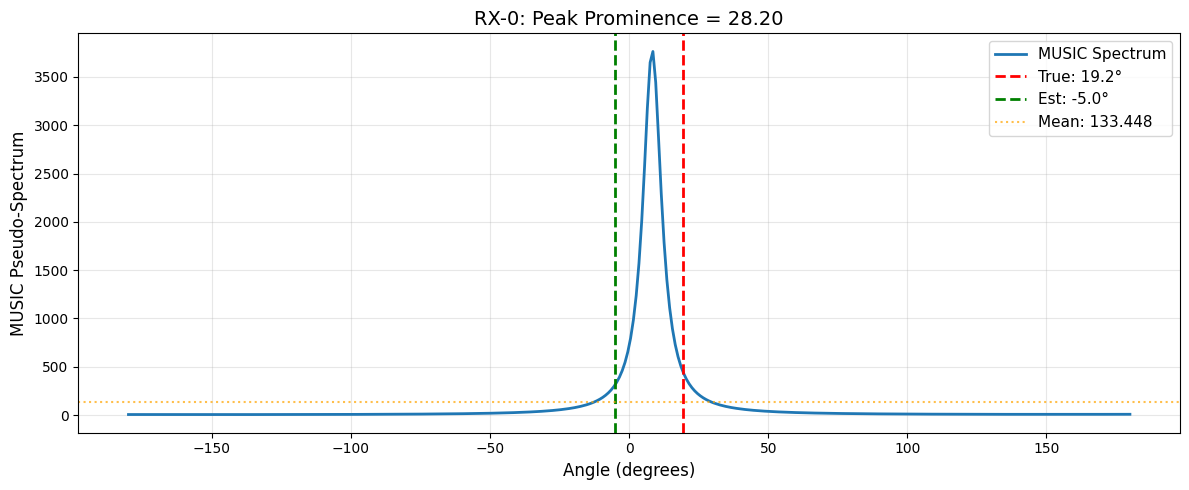


RX-1 (AP) at [[-5.3, 0.5, 1.9]] measuring TX-0 at [[3.6, 0.3, 1.2]]
  True range: 8.93m
  True angle: -4.5°
  Direction vector (X, Z): [[ 8.9      ]
 [-0.6999999]]


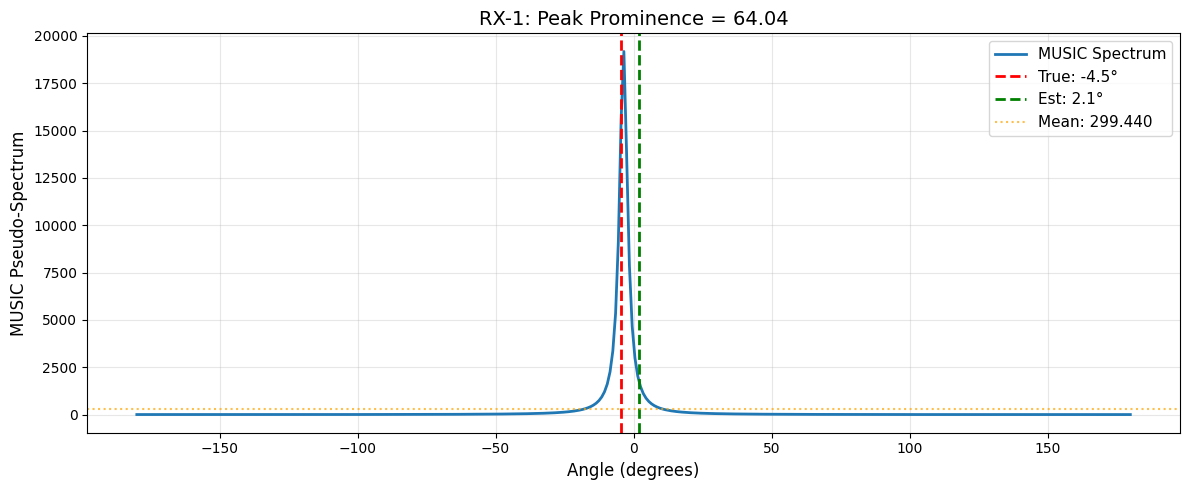


RX-2 (AP) at [[5.3, 0.5, -1.9]] measuring TX-0 at [[3.6, 0.3, 1.2]]
  True range: 3.54m
  True angle: 118.7°
  Direction vector (X, Z): [[-1.7000003]
 [ 3.1      ]]


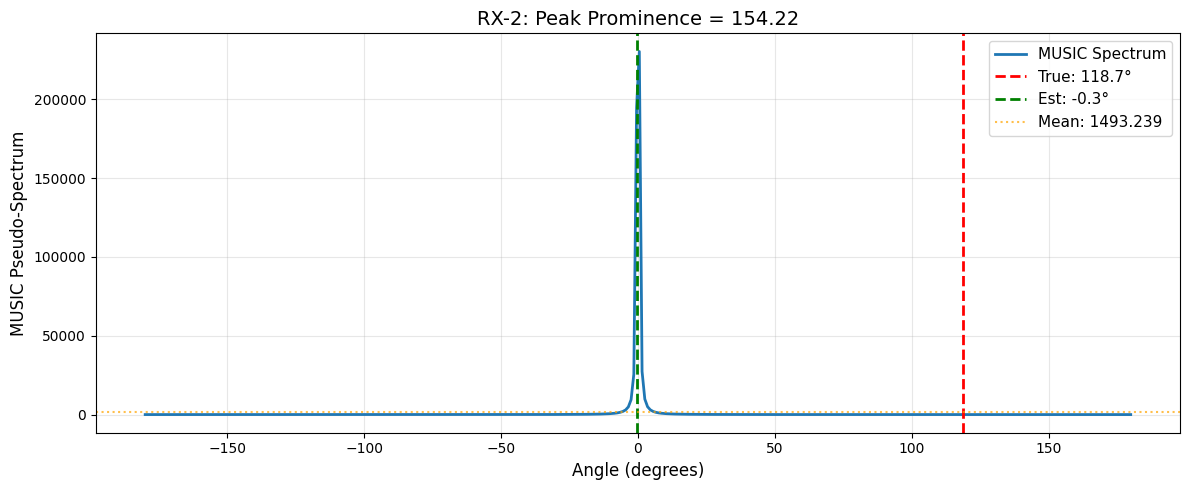


RX-3 (AP) at [[5.3, 0.5, 1.9]] measuring TX-0 at [[3.6, 0.3, 1.2]]
  True range: 1.85m
  True angle: -157.6°
  Direction vector (X, Z): [[-1.7000003]
 [-0.6999999]]


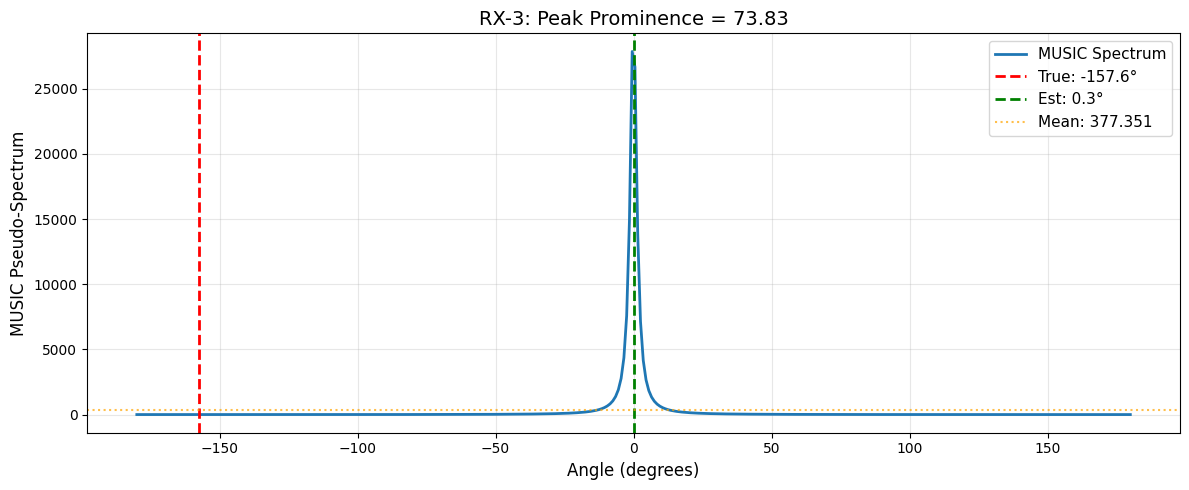

In [ ]:
# Impairment Functions
SNR_DB = 20.0
ANTENNA_PHASE_STATIC_STD = np.deg2rad(5.0)
ANTENNA_GAIN_STATIC_STD = 0.05
CFO_PPM = 5.0
CFO_JITTER_PPM = 0.5
SNAPSHOT_PHASE_JITTER_STD = 0.2
QUANTIZATION_BITS = 8

# Extract amplitudes and delays from paths
a, tau = paths.cir(normalize_delays=False, out_type="numpy")
a_snap = a[..., 0] 
tau_snap = tau

num_rx = a_snap.shape[0]
num_rx_ant = a_snap.shape[1]
num_tx = a_snap.shape[2]
num_tx_ant = a_snap.shape[3]

range_estimator = FTMRangeEstimator()
solver = HybridLocalizationSolver()

aoa_estimator = CSIAngleEstimator(num_rx_ant, WAVELENGTH, rx_array=scene.rx_array)
enhanced_aoa_estimator = EnhancedAoAEstimator(num_rx_ant, WAVELENGTH)
enhanced_range_estimator = EnhancedFTMRangeEstimator()
nlos_solver = NLOSAwareHybridLocalizationSolver()

target_tx_idx = 0
tx_list[target_tx_idx].position = tx_positions[target_tx_idx]
true_target_position = np.array(tx_list[target_tx_idx].position).flatten()

all_estimated_ranges = []
all_estimated_angles = []
all_anchor_positions = []
all_nlos_mitigated_ranges = []
all_nlos_mitigated_angles = []
all_nlos_probabilities = []

for rx_idx in range(num_rx):
    rx_pos = rx_list[rx_idx].position
    tx_pos = tx_list[target_tx_idx].position
    
    true_range = np.linalg.norm(tx_pos - rx_pos)
    direction = np.array([tx_pos[0] - rx_pos[0], tx_pos[2] - rx_pos[2]])  # [X, Z]
    true_angle = np.arctan2(direction[1], direction[0])  # arctan2(Z_diff, X_diff)
    if isinstance(true_angle, np.ndarray):
        true_angle = float(true_angle.item())
    
    print(f"RX-{rx_idx} (AP) at {rx_pos} measuring TX-{target_tx_idx} at {tx_pos}")
    print(f"  True range: {true_range:.2f}m")
    print(f"  True angle: {np.rad2deg(true_angle):.1f}°")
    print(f"  Direction vector (X, Z): {direction}")
    
    # Create ideal channel state representation
    H_freq_base = np.zeros((NUM_SUBCARRIERS, num_rx_ant), dtype=np.complex128)
    
    for rx_ant in range(num_rx_ant):
        for tx_ant in range(num_tx_ant):
            delays = tau_snap[rx_idx, target_tx_idx, :]
            complex_amplitudes = a_snap[rx_idx, rx_ant, target_tx_idx, tx_ant, :]
            for l in range(num_paths):
                H_freq_base[:, rx_ant] += complex_amplitudes[l] * np.exp(-1j * 2*np.pi * delays[l] * subcarriers)
    
    csi_mimo_ideal = H_freq_base.T 

    # Apply non-idealities
    H_noisy = csi_mimo_ideal.copy()
    
    H_noisy = add_antenna_offsets(H_noisy, ANTENNA_PHASE_STATIC_STD, ANTENNA_GAIN_STATIC_STD, rng)
    H_noisy = add_cfo(H_noisy, CFO_PPM, subcarrier_indices, SUBCARRIER_SPACING, rng, CFO_JITTER_PPM)
    H_noisy = add_snapshot_jitter(H_noisy, SNAPSHOT_PHASE_JITTER_STD, 0.0, rng)
    H_noisy = add_awgn(H_noisy, SNR_DB, rng)
    final_csi_noisy = H_noisy
    
    # Apply compensation
    compensated_csi = final_csi_noisy.copy()
    compensated_csi = compensate_cfo(compensated_csi, subcarrier_indices)
    compensated_csi = compensate_phase_jitter(compensated_csi)
    compensated_csi = compensate_antenna_offsets(compensated_csi)
    
    # Get path delays and amplitudes for both methods
    delays = tau_snap[rx_idx, target_tx_idx, :]
    amplitudes = np.mean([a_snap[rx_idx, ant, target_tx_idx, 0, :] for ant in range(num_rx_ant)], axis=0)
    
    # Original hybrid localization
    estimated_angle, spectrum = aoa_estimator.estimate_aoa_music(compensated_csi, return_spectrum=True)
    peak_prominence = spectrum.max() / (np.mean(spectrum)+1e-12)
    
    # Plot MUSIC spectrum
    angles_deg = np.rad2deg(np.linspace(-np.pi, np.pi, len(spectrum)))
    plt.figure(figsize=(12, 5))
    plt.plot(angles_deg, spectrum, linewidth=2, label='MUSIC Spectrum')
    plt.axvline(np.rad2deg(true_angle), color='r', linestyle='--', linewidth=2, label=f'True: {np.rad2deg(true_angle):.1f}°')
    plt.axvline(np.rad2deg(estimated_angle), color='g', linestyle='--', linewidth=2, label=f'Est: {np.rad2deg(estimated_angle):.1f}°')
    plt.axhline(np.mean(spectrum), color='orange', linestyle=':', alpha=0.7, label=f'Mean: {np.mean(spectrum):.3f}')
    plt.xlabel('Angle (degrees)', fontsize=12)
    plt.ylabel('MUSIC Pseudo-Spectrum', fontsize=12)
    plt.title(f'RX-{rx_idx}: Peak Prominence = {peak_prominence:.2f}', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Check steering vectors at true angle
    a_true = aoa_estimator.steering_vector(true_angle, elevation=0)
    
    csi_phases = np.angle(compensated_csi[:, 0])
    
    if peak_prominence < 3: 
        estimated_angle = np.nan
    
    estimated_range = range_estimator.estimate_range_from_cir(delays, amplitudes)

    all_estimated_ranges.append(estimated_range)
    all_estimated_angles.append(float(estimated_angle))
    all_anchor_positions.append(rx_pos)
    
    # NLOS Mitigated Method
    nlos_angle, nlos_spectrum, nlos_peak_prominence = enhanced_aoa_estimator.estimate_aoa_music_nlos_robust(
        compensated_csi, delays=delays, amplitudes=amplitudes, return_spectrum=True
    )
    
    a_true = aoa_estimator.steering_vector(true_angle, elevation=0)

    M = compensated_csi.shape[0]
    N = compensated_csi.shape[1]
    
    R_forward = compensated_csi @ compensated_csi.conj().T / N
    J = np.fliplr(np.eye(M))
    R = (R_forward + J @ R_forward.conj() @ J) / 2
    
    eigenvalues, eigenvectors = np.linalg.eigh(R)
    idx = eigenvalues.argsort()[::-1]
    
    num_sources = 1
    noise_subspace = eigenvectors[:, idx[num_sources:]] 
    
    a_true_H_P_N_a_true = np.abs(a_true.conj() @ noise_subspace @ noise_subspace.conj().T @ a_true)
    
    if peak_prominence < 3: 
        estimated_angle = np.nan
    
    nlos_range, is_nlos, nlos_prob = enhanced_range_estimator.estimate_range_nlos_mitigated(delays, amplitudes)
    _, _, nlos_metrics = enhanced_range_estimator.detect_nlos(delays, amplitudes)
    
    all_nlos_mitigated_ranges.append(nlos_range)
    all_nlos_mitigated_angles.append(float(nlos_angle))
    all_nlos_probabilities.append(nlos_prob)

In [ ]:
anchor_pos_array_final = np.array(all_anchor_positions)
ranges_final = np.array(all_estimated_ranges)
angles_final = np.array(all_estimated_angles)

nlos_ranges_final = np.array(all_nlos_mitigated_ranges)
nlos_angles_final = np.array(all_nlos_mitigated_angles)
nlos_probs_final = np.array(all_nlos_probabilities)

true_target_position_flat = np.asarray(true_target_position).flatten()

# Hybrid Localization (Original)
try:
    estimated_position_hybrid = solver.hybrid_localization(
        anchor_pos_array_final,
        ranges_final,
        angles_final,
        distance_std=0.5, 
        angle_std=np.deg2rad(5)
    )

    estimated_position_hybrid = np.asarray(estimated_position_hybrid).flatten()
    localization_error_hybrid = np.linalg.norm(estimated_position_hybrid - true_target_position_flat)
    error_xyz_hybrid = estimated_position_hybrid - true_target_position_flat

    print(f"Original Hybrid Localization Results:")
    print(f"Localization Error: {localization_error_hybrid:.3f} meters")
    print(f"True TX Position:      [{true_target_position_flat[0]:.2f}, {true_target_position_flat[1]:.2f}, {true_target_position_flat[2]:.2f}]")
    print(f"Estimated TX Position: [{estimated_position_hybrid[0]:.2f}, {estimated_position_hybrid[1]:.2f}, {estimated_position_hybrid[2]:.2f}]")
    
    print(f"\nPer-Dimension Errors:")
    print(f"  X-axis error: {error_xyz_hybrid[0]:+.3f} m")
    print(f"  Y-axis error: {error_xyz_hybrid[1]:+.3f} m")
    print(f"  Z-axis error: {error_xyz_hybrid[2]:+.3f} m")
    
except Exception as e:
    print(f"\n Original localization failed: {type(e).__name__}: {str(e)}")
    estimated_position_hybrid = None
    localization_error_hybrid = np.inf

# NLOS Mitigated Hybrid Localization
try:
    estimated_position_nlos = nlos_solver.hybrid_localization_nlos_aware(
        anchor_pos_array_final,
        nlos_ranges_final,
        nlos_angles_final,
        nlos_probs=nlos_probs_final,
        distance_std=0.5, 
        angle_std=np.deg2rad(5)
    )
    
    estimated_position_nlos = np.asarray(estimated_position_nlos).flatten()
    localization_error_nlos = np.linalg.norm(estimated_position_nlos - true_target_position_flat)
    error_xyz_nlos = estimated_position_nlos - true_target_position_flat
    
    print(f"NLOS Mitigated Hybrid Results:")
    print(f"True TX Position:      [{true_target_position_flat[0]:.2f}, {true_target_position_flat[1]:.2f}, {true_target_position_flat[2]:.2f}]")
    print(f"Estimated TX Position: [{estimated_position_nlos[0]:.2f}, {estimated_position_nlos[1]:.2f}, {estimated_position_nlos[2]:.2f}]")
    print(f"Localization Error: {localization_error_nlos:.3f} meters")
    
    print(f"\nPer-Dimension Errors:")
    print(f"  X-axis error: {error_xyz_nlos[0]:+.3f} m")
    print(f"  Y-axis error: {error_xyz_nlos[1]:+.3f} m")
    print(f"  Z-axis error: {error_xyz_nlos[2]:+.3f} m")
    
except Exception as e:
    print(f"\n NLOS-mitigated localization failed: {type(e).__name__}: {str(e)}")
    estimated_position_nlos = None
    localization_error_nlos = np.inf

Original Hybrid Localization Results:
Localization Error: 3.556 meters
True TX Position:      [3.60, 0.30, 1.20]
Estimated TX Position: [5.34, 0.28, -1.90]

 Original localization failed: NameError: name 'localization_error' is not defined
NLOS Mitigated Hybrid Results:
True TX Position:      [3.60, 0.30, 1.20]
Estimated TX Position: [5.31, 3.88, -1.89]
Localization Error: 5.028 meters

Per-Dimension Errors:
  X-axis error: +1.711 m
  Y-axis error: +3.579 m
  Z-axis error: -3.089 m


C:\Users\pokem\AppData\Local\Temp\ipykernel_11184\4160228944.py:157: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  anchor_x = float(anchor_positions[i, 0])
C:\Users\pokem\AppData\Local\Temp\ipykernel_11184\4160228944.py:158: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  anchor_z = float(anchor_positions[i, 2])
C:\Users\pokem\AppData\Local\Temp\ipykernel_11184\4160228944.py:157: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  anchor_x = float(anchor_positions[i, 0])
C

In [9]:
if 'anchor_pos_array_final' in locals():
    anchor_pos_array_final_cmp = np.asarray(anchor_pos_array_final)
else:
    anchor_pos_array_final_cmp = anchor_positions

true_target_position_flat = np.asarray(true_target_position).flatten()
true_ranges_list = []
for i in range(len(anchor_pos_array_final_cmp)):
    anchor_pos = anchor_pos_array_final_cmp[i].flatten()
    true_range = np.linalg.norm(true_target_position_flat - anchor_pos[:len(true_target_position_flat)])
    true_ranges_list.append(true_range)

if 'ranges_final' in locals():
    orig_range_errors = [abs(float(ranges_final[i]) - true_ranges_list[i]) for i in range(len(ranges_final))]
else:
    orig_range_errors = [np.nan] * len(true_ranges_list)

if 'nlos_ranges_final' in locals():
    nlos_range_errors = [abs(float(nlos_ranges_final[i]) - true_ranges_list[i]) for i in range(len(nlos_ranges_final))]
else:
    nlos_range_errors = [np.nan] * len(true_ranges_list)

if 'measured_ranges' in locals():
    range_only_errors = [abs(float(measured_ranges[i]) - true_ranges_list[i]) for i in range(len(measured_ranges))]
else:
    range_only_errors = [np.nan] * len(true_ranges_list)

print(f"Localization Accuracy Comparison")
print(f"\n  {'Method':<30} {'3D Error (m)':<15} {'X-Err (m)':<12} {'Y-Err (m)':<12} {'Z-Err (m)':<12}")

# Range-Only method
if 'localization_error_range_only' in locals() and 'error_xyz_range_only' in locals():
    print(f"  {'Range-Only (One-Way)':<30} {localization_error_range_only:<15.3f} {error_xyz_range_only[0]:<+12.3f} {error_xyz_range_only[1]:<+12.3f} {error_xyz_range_only[2]:<+12.3f}")
else:
    print(f"  {'Range-Only (One-Way)':<30} {'NOT COMPUTED':<15}")

# Original Hybrid method
if 'localization_error_hybrid' in locals() and 'error_xyz_hybrid' in locals():
    print(f"  {'Original Hybrid (CSI+AoA)':<30} {localization_error_hybrid:<15.3f} {error_xyz_hybrid[0]:<+12.3f} {error_xyz_hybrid[1]:<+12.3f} {error_xyz_hybrid[2]:<+12.3f}")
else:
    print(f"  {'Original Hybrid (CSI+AoA)':<30} {'NOT COMPUTED':<15}")

# NLOS-Mitigated Hybrid method
if 'localization_error_nlos' in locals() and 'error_xyz_nlos' in locals():
    print(f"  {'NLOS-Mitigated Hybrid':<30} {localization_error_nlos:<15.3f} {error_xyz_nlos[0]:<+12.3f} {error_xyz_nlos[1]:<+12.3f} {error_xyz_nlos[2]:<+12.3f}")
else:
    print(f"  {'NLOS-Mitigated Hybrid':<30} {'NOT COMPUTED':<15}")

# Find best method
errors = {}
if 'localization_error_range_only' in locals() and localization_error_range_only != np.inf:
    errors['Range-Only (One-Way)'] = localization_error_range_only
if 'localization_error_hybrid' in locals() and localization_error_hybrid != np.inf:
    errors['Original Hybrid (CSI+AoA)'] = localization_error_hybrid
if 'localization_error_nlos' in locals() and localization_error_nlos != np.inf:
    errors['NLOS-Mitigated Hybrid'] = localization_error_nlos

if errors:
    best_method = min(errors, key=errors.get)
    worst_method = max(errors, key=errors.get)
    print(f"\n  Best Method:  {best_method} (Error: {errors[best_method]:.3f}m)")
    print(f"  Worst Method: {worst_method} (Error: {errors[worst_method]:.3f}m)")
    
    improvement = errors[worst_method] - errors[best_method]
    improvement_pct = (improvement / errors[worst_method]) * 100 if errors[worst_method] > 0 else 0
    print(f"  Improvement: {improvement:.3f}m ({improvement_pct:.1f}% reduction)")
else:
    print(f"\n No valid localization results to compare")

# NLOS-Mitigation Analysis
if 'localization_error_hybrid' in locals() and 'localization_error_nlos' in locals() and \
   localization_error_hybrid != np.inf and localization_error_nlos != np.inf:
    print(f"\nNLOS Mitigation Improvement Analysis")
    
    nlos_improvement = localization_error_hybrid - localization_error_nlos
    nlos_improvement_pct = (nlos_improvement / localization_error_hybrid) * 100 if localization_error_hybrid > 0 else 0
    
    print(f"\n  NLOS Mitigation Effect on Hybrid Method:")
    print(f"    Original Error:        {localization_error_hybrid:.3f} m")
    print(f"    NLOS-Mitigated Error:  {localization_error_nlos:.3f} m")
    print(f"    Error Reduction:       {nlos_improvement:+.3f} m")
    print(f"    Improvement:           {nlos_improvement_pct:+.1f}%")

Localization Accuracy Comparison

  Method                         3D Error (m)    X-Err (m)    Y-Err (m)    Z-Err (m)   
  Range-Only (One-Way)           2.944           +0.037       +0.200       +2.937      
  Original Hybrid (CSI+AoA)      3.556           +1.741       -0.024       -3.101      
  NLOS-Mitigated Hybrid          5.028           +1.711       +3.579       -3.089      

  Best Method:  Range-Only (One-Way) (Error: 2.944m)
  Worst Method: NLOS-Mitigated Hybrid (Error: 5.028m)
  Improvement: 2.084m (41.4% reduction)

NLOS Mitigation Improvement Analysis

  NLOS Mitigation Effect on Hybrid Method:
    Original Error:        3.556 m
    NLOS-Mitigated Error:  5.028 m
    Error Reduction:       -1.472 m
    Improvement:           -41.4%
